# Lab Instructions

Find a dataset that interests you. I'd recommend starting on [Kaggle](https://www.kaggle.com/). Read through all of the material about the dataset and download a .CSV file.

1. Write a short summary of the data.  Where did it come from?  How was it collected?  What are the features in the data?  Why is this dataset interesting to you?  

2. Identify 5 interesting questions about your data that you can answer using Pandas methods.  

3. Answer those questions!  You may use any method you want (including LLMs) to help you write your code; however, you should use Pandas to find the answers.  LLMs will not always write code in this way without specific instruction.  

4. Write the answer to your question in a text box underneath the code you used to calculate the answer.



In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('twitchdata-update-selected-columns.csv')
df.head()

,Channel,Watch time(Minutes),Stream time(minutes),Peak viewers,Average viewers,Followers,Followers gained,Views gained,Partnered,Mature
0,xQcOW,6196161750,215250,222720,27716,3246298,1734810,93036735,True,False
1,summit1g,6091677300,211845,310998,25610,5310163,1370184,89705964,True,False
2,Gaules,5644590915,515280,387315,10976,1767635,1023779,102611607,True,True
3,ESL_CSGO,3970318140,517740,300575,7714,3944850,703986,106546942,True,False
4,Tfue,3671000070,123660,285644,29602,8938903,2068424,78998587,True,False


This dataset contains performance metrics for top Twitch streamers and was sourced from Kaggle.
It includes the following features:

- Channel
- Watch time (Minutes)
- Stream time (Minutes)
- Peak viewers
- Average viewers
- Followers
- Followers gained
- Views gained
- Partnered (True/False)
- Mature (True/False)

The data focuses on high-performing Twitch channels and captures engagement, growth, and streaming activity.
This dataset is interesting to me because I’m building a site called VODForge, a tool that helps streamers automatically generate and post short-form clips. Understanding patterns among successful streamers (watch time, average viewers, follower growth, streaming volume, etc.) is directly relevant to the product and the market I’m targeting.

In [ ]:
Questions:

1. Which streamers have the highest average viewers?
2. Is there a relationship between stream time and watch time?
3. Do Partnered streamers tend to have more followers than non-Partnered ones?
4. Which channels gained the most followers?
5. How does Peak viewers compare to Average viewers across the top streamers?

          Channel  Average viewers
81        dota2ti           147643
109    dota2ti_ru           126232
14      auronplay            53986
41            LCS            46459
13         Rubius            42948
5       Asmongold            42414
21      LCK_Korea            39848
52   RocketLeague            36086
46            LCK            36030
990      KEEMSTAR            35333


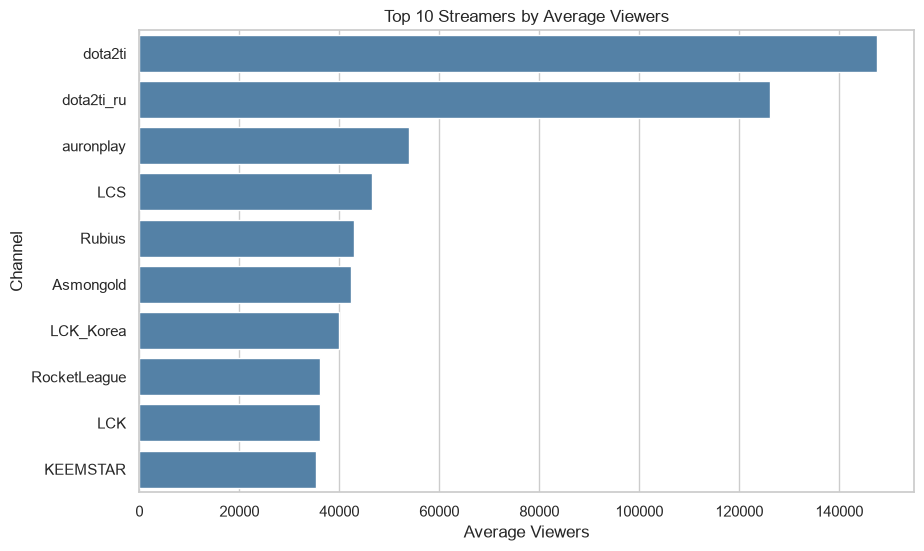

In [3]:
top_avg = df.nlargest(10, 'Average viewers')[['Channel', 'Average viewers']]
print(top_avg)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_avg, x='Average viewers', y='Channel', color='steelblue')
plt.title('Top 10 Streamers by Average Viewers')
plt.xlabel('Average Viewers')
plt.ylabel('Channel')
plt.show()

In [ ]:
The streamers with the highest average viewers are dominated by major esports and tournament channels. 
dota2ti and dota2ti_ru lead by a large margin (over 120k–147k average viewers), followed by big individual creators like auronplay, Rubius, and Asmongold.
This shows that official tournament broadcasts tend to pull much higher average concurrent viewers than even the biggest individual streamers.

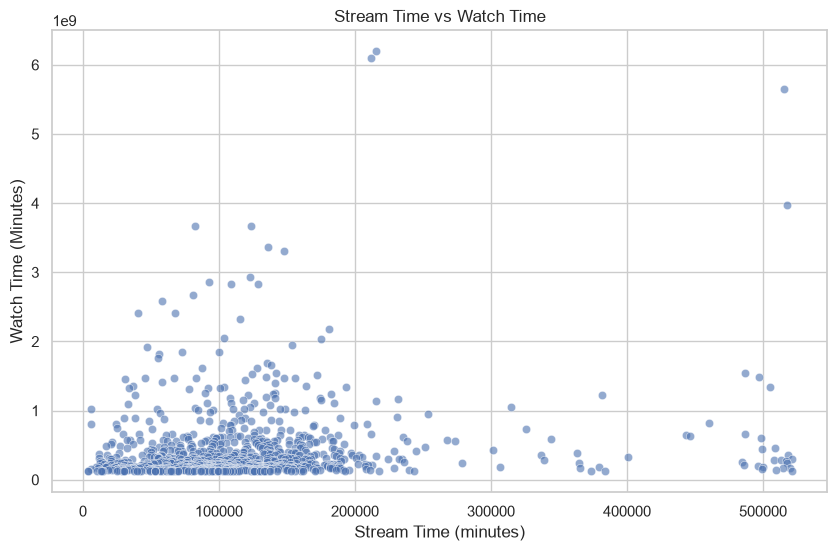

Correlation between Stream Time and Watch Time: 0.151


In [4]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Stream time(minutes)', y='Watch time(Minutes)', alpha=0.6)
plt.title('Stream Time vs Watch Time')
plt.xlabel('Stream Time (minutes)')
plt.ylabel('Watch Time (Minutes)')
plt.show()

# Optional: correlation
correlation = df['Stream time(minutes)'].corr(df['Watch time(Minutes)'])
print(f"Correlation between Stream Time and Watch Time: {correlation:.3f}")

In [ ]:
There is only a very weak positive relationship between stream time and watch time (correlation ≈ 0.15).
Many channels that stream a lot still have relatively low total watch time, while some of the highest watch-time channels do not necessarily stream the most hours. This suggests that streaming more hours does not automatically lead to higher total watch time. Content quality, audience size, and consistency matter more than raw hours streamed.

Partnered
False    331942.681818
True     575410.356851
Name: Followers, dtype: float64


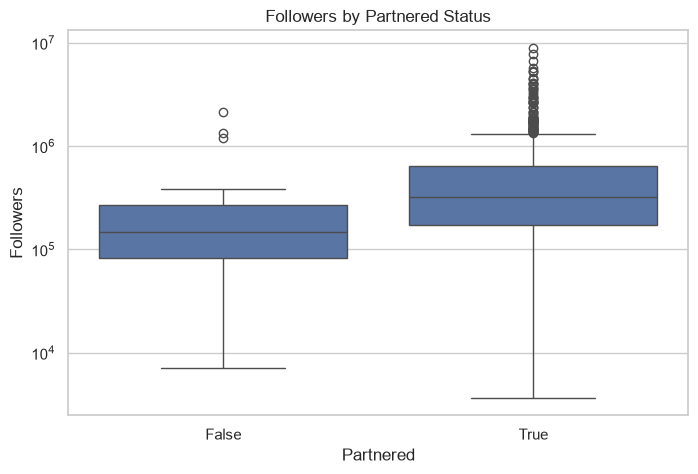

In [5]:
# Compare average followers
partnered_avg = df.groupby('Partnered')['Followers'].mean()
print(partnered_avg)

# Visualization
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Partnered', y='Followers')
plt.title('Followers by Partnered Status')
plt.xlabel('Partnered')
plt.ylabel('Followers')
plt.yscale('log')  # log scale helps because follower counts vary a lot
plt.show()

In [ ]:
Yes, Partnered streamers tend to have more followers than non-Partnered ones.

Average followers for Partnered channels: ~575,000
Average followers for non-Partnered channels: ~332,000

The boxplot also shows that Partnered streamers generally sit higher in the follower distribution, although there is still a wide range in both groups. This makes sense, since becoming Partnered usually requires already having a solid audience.

       Channel  Followers gained
14   auronplay           3966525
13      Rubius           3820532
25    TheGrefg           3593081
51       Bugha           2220765
90    pokimane           2085831
4         Tfue           2068424
40       Fresh           1875187
669   SLAKUN10           1874846
0        xQcOW           1734810
54        Clix           1687923


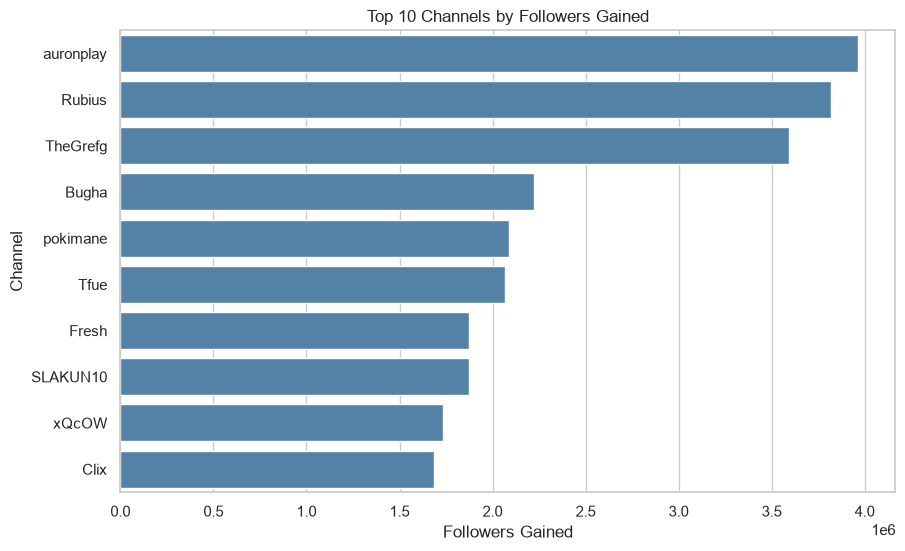

In [6]:
top_gained = df.nlargest(10, 'Followers gained')[['Channel', 'Followers gained']]
print(top_gained)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_gained, x='Followers gained', y='Channel', color='steelblue')
plt.title('Top 10 Channels by Followers Gained')
plt.xlabel('Followers Gained')
plt.ylabel('Channel')
plt.show()

In [ ]:
The channels that gained the most followers are led by large Spanish-speaking creators:

auronplay (~3.97 million)
Rubius (~3.82 million)
TheGrefg (~3.59 million)

They are followed by big English-speaking creators like Bugha, pokimane, and Tfue.
This shows that during the period of this dataset, several of the fastest-growing channels were Spanish-language streamers, highlighting how strong the Spanish-speaking Twitch audience was at the time.

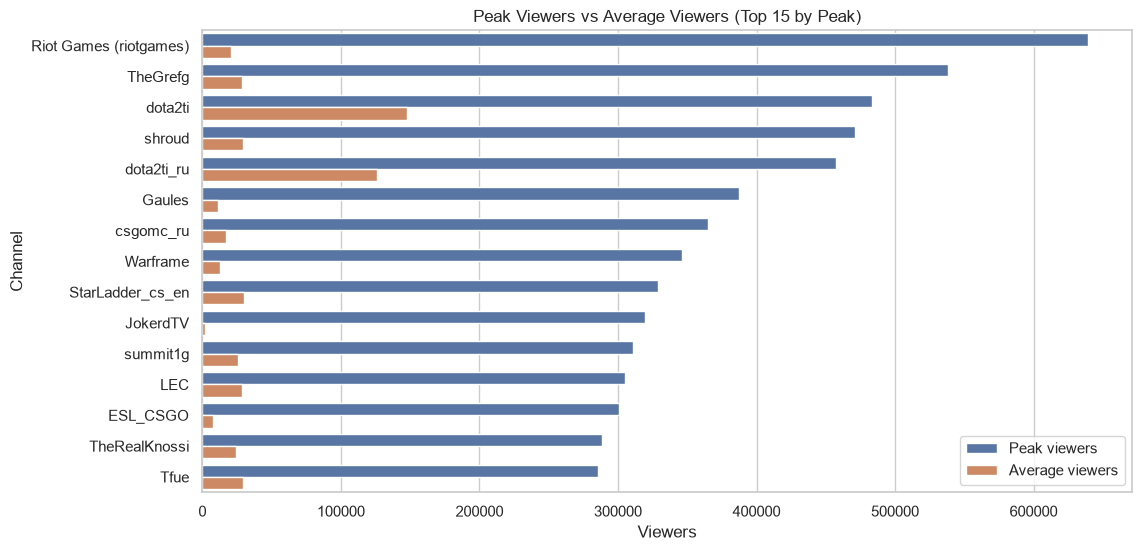

In [7]:
# Look at the top 15 channels by Peak viewers
top_peak = df.nlargest(15, 'Peak viewers')[['Channel', 'Peak viewers', 'Average viewers']]

plt.figure(figsize=(12, 6))
top_peak_melted = top_peak.melt(id_vars='Channel', value_vars=['Peak viewers', 'Average viewers'],
                                 var_name='Metric', value_name='Viewers')

sns.barplot(data=top_peak_melted, x='Viewers', y='Channel', hue='Metric')
plt.title('Peak Viewers vs Average Viewers (Top 15 by Peak)')
plt.xlabel('Viewers')
plt.ylabel('Channel')
plt.legend(title='')
plt.show()

In [ ]:
Peak viewers are much higher than average viewers for nearly every top channel.
Many of the highest peaks come from official esports/tournament channels (Riot Games, dota2ti, LEC, ESL_CSGO, etc.) and big event streams. Even among individual streamers, the gap between their peak and their average is large.
This is expected, peaks usually happen during special events, tournaments, or viral moments, while average viewers reflect more typical day-to-day performance.